# Chicago Nighthawk Project Occupancy Modeling Analysis


For the last 3 years, I have participated in the [Chicago Nighthawk Project](https://www.chicagobirder.org/chicago-nighthawk-project), a citzen science project that monitors the urban population of Common Nighthawks (Chordeiles minor). Recently, I attented a talk presented by Timm Haucke on Occupancy Modeling using his sofware biolith at the International Conservation Technology Conference in Lima, Peru. Because of the way the Nighthawk Project protocol was designed, it was immediately clear that this mapped to analysis methods in the field of Occupancy Modeling. This notebook is an exploration of that mapping. A primary question I want to answer is whether insights could be gathered from such a relatively small and short term, though still multi-year, study. In particular, I wanted to know if we could statistically prove that the increase in sites monitored every year improved the quality of the results.

## Download Data



First, mount Google Drive and set the DATA_DIR constant.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/My Drive/Colab Notebooks/data')
print(f"DATA_DIR is set to: {DATA_DIR}")

Mounted at /content/drive
DATA_DIR is set to: /content/drive/My Drive/Colab Notebooks/data


## Install Dependencies

---



In [27]:
# Install dependencies (safe to re-run)
import importlib.util
import subprocess
import sys

requirements = [
    "biolith",
    "numpy",
    "pandas",
    "scipy",
    "matplotlib",
    "seaborn",
    # plotly was orignally used for Plotly Express, which creates JS charts that
    # don't open easily on GitHub
    # "plotly",
    "scikit-learn",
    "arviz",
    "ipywidgets",
    # maps
    "contextily",
    "geopandas"
]

module_map = {
    "scikit-learn": "sklearn",
}

missing = []
for pkg in requirements:
    module = module_map.get(pkg, pkg.replace("-", "_"))
    if importlib.util.find_spec(module) is None:
        missing.append(pkg)

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages already installed.")

All required packages already installed.


In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from biolith.models import occu
from biolith.utils import fit, predict
from biolith.evaluation import lppd

# Feel free to tune these
NUM_WARMUP = 500
NUM_SAMPLES = 500
NUM_CHAINS = 3
RANDOM_SEED = 42

sns.set_theme(style="whitegrid")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))

## 1) Load and inspect the raw data

In [17]:
obs_23 = pd.read_csv(DATA_DIR / "2023.csv")
obs_24 = pd.read_csv(DATA_DIR / "2024.csv")
obs_25 = pd.read_csv(DATA_DIR / "2025.csv")

print("2023 Preview")
print("Shape:", obs_23.shape)
# print(ann_23["Period 1"].value_counts())
print("Head:")
display(obs_23.head(3))

print("2024 shape:", obs_24.shape)
# print(ann_24["Period 1 (june 9-15)"].value_counts())
display(obs_24.head(3))

print("2025 shape:", obs_25.shape)
# print(ann_25["Period 1 (june 9-15)"].value_counts())
display(obs_25.head(3))

2023 Preview
Shape: (130, 8)
Head:


,Latitude,Longitude,Location ID,Period 1,Period 2,Period 3,Totals Obsv,Max Count
0,41.83986,-87.64815,McGuane Park,0,-,-,0,0.0
1,41.83451,-87.63504,Armour Sq/ Sox Park,0,-,-,0,0.0
2,41.83470,-87.62500,IIT,0,-,-,0,0.0


2024 shape: (135, 9)


,Latitude,Longitude,Location ID,Period 1 (june 9-15),Period 2 (june 16-22),Period 3 (june 23-29),Total coni Obsv,Max Count,Unnamed: 8
0,41.962615,-87.648956,Chicago Nighthawk Project 4,0,0,0,0.0,0.0,NaN
1,41.951895,-87.642011,Chicago Nighthawk Project Point 2,0,0,0,0.0,0.0,NaN
2,41.956492,-87.648625,Chicago Nighthawk Project Point 3,0,0,0,0.0,0.0,NaN


2025 shape: (240, 8)


,Latitude,Longitude,Location ID,Period 1 (june 9-15),Period 2 (june 16-22),Period 3 (june 23-29),Total coni Obsv,Max Count
0,42.016203,-87.677326,Pottawattomie Park,2,2,1,5,2
1,42.024555,-87.684995,St. Francis Hospital,0,0,0,0,0
2,42.02822,-87.689275,Kaman Park,0,0,0,0,0


## 2) Clean data

### Define cleanup function


In [15]:
def clean_obs_df(obs_df):
  col_rename_map = {"Period 1 (june 9-15)": "A",
                    "Period 1": "A",
                    "Period 2 (june 16-22)": "B",
                    "Period 2": "B",
                    "Period 3 (june 23-29)": "C",
                    "Period 3": "C",
                    }
  drop_columns = ['Total coni Obsv', 'Max Count', 'Unnamed: 8', 'Totals Obsv']
  obs_df.rename(columns=col_rename_map, inplace=True)
  obs_df.drop(columns=drop_columns, inplace=True, errors='ignore')

  # Convert columns to string type for cleanup
  obs_df = obs_df.astype(str)

  # Define a combined filter condition for invalid entries
  # For now, this includes any row with a NAN value for sitings, but a future
  # Occupancy Model should take these into account
  # This filters out rows if any of the detection columns contain '-', ' ' (for 'C'), or 'nan' (for 'C')
  filter_condition = obs_df['A'].str.contains('-') | \
                     obs_df['B'].str.contains('-') | \
                     obs_df['C'].str.contains('-') | \
                     obs_df['C'].str.contains(' ') | \
                     obs_df['C'].str.contains('nan')
  obs_df = obs_df[~filter_condition].copy()

  # Set the index here so that we can deal with all values as ints going forward
  if obs_df.index.name != 'Location ID':
    obs_df.set_index("Location ID", inplace=True)

  # create 2 dataframes for return value, 1 a binary matrix (TODO: term?) and the other including lat/long
  for colname in ['A', 'B', 'C']:
    obs_df[colname] = obs_df[colname].astype(int)
      # Convert to 0 or 1 for obs or non-obs - we don't care about the number of
      # observations per site.

    obs_df[colname] = (obs_df[colname] != 0).astype(int)
  # obs_df = (obs_df != 0).astype(int)
  obs_only_df = obs_df.drop(columns=['Latitude', 'Longitude'], errors='ignore')

  return obs_only_df, obs_df



### Run cleanup function and view data


In [18]:
obs_23, obs_geo_23 = clean_obs_df(obs_23)
obs_24, obs_geo_24 = clean_obs_df(obs_24)
obs_25, obs_geo_25 = clean_obs_df(obs_25)

print('2023')
n_sites, n_visits = obs_23.shape
obs_cov_empty_23 = np.zeros((n_sites, n_visits, 0), dtype=float)
print("obs_23 shape:", obs_23.shape)
print("Observed positives:", int(obs_23.values.sum()), "out of", obs_23.size)
display(obs_23.head(3))
display(obs_geo_23.head(3))
print('----')

print('2024')
n_sites, n_visits = obs_24.shape
obs_cov_empty_24 = np.zeros((n_sites, n_visits, 0), dtype=float)
print("obs_24 shape:", obs_24.shape)
print("Observed positives:", int(obs_24.values.sum()), "out of", obs_24.size)
display(obs_24.head(3))
print('----')

print('2025')
n_sites, n_visits = obs_25.shape
obs_cov_empty_25 = np.zeros((n_sites, n_visits, 0), dtype=float)
print("obs_25 shape:", obs_25.shape)
print("Observed positives:", int(obs_25.values.sum()), "out of", obs_25.size)
display(obs_25.head(3))
print('----')



2023
obs_23 shape: (71, 3)
Observed positives: 57 out of 213


,A,B,C
Location ID,,,
2001 S Batavia Ave,0,1,0
719 S Batavia Ave,1,1,1
610 Franklin St,1,1,1


,Latitude,Longitude,A,B,C
Location ID,,,,,
2001 S Batavia Ave,41.866,-88.312,0,1,0
719 S Batavia Ave,41.879,-88.307,1,1,1
610 Franklin St,41.886,-88.313,1,1,1


----
2024
obs_24 shape: (98, 3)
Observed positives: 67 out of 294


,A,B,C
Location ID,,,
Chicago Nighthawk Project 4,0,0,0
Chicago Nighthawk Project Point 2,0,0,0
Chicago Nighthawk Project Point 3,0,0,0


----
2025
obs_25 shape: (137, 3)
Observed positives: 100 out of 411


,A,B,C
Location ID,,,
Pottawattomie Park,1,1,1
St. Francis Hospital,0,0,0
Kaman Park,0,0,0


----


## Show summary for each year

In [ ]:
# year, num sites, num sites w/ pos obs, num overall pos obs at site


In [21]:
import folium

# Install folium if not already installed
try:
    import folium
except ImportError:
    !pip install -q folium
    import folium

# Define central coordinates for Chicago
chicago_coords = [41.8781, -87.6298]

# Create a folium map centered on Chicago
m = folium.Map(location=chicago_coords, zoom_start=10)

# Add markers for each location in obs_geo_23
for index, row in obs_geo_23.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=index  # Using Location ID as popup text
    ).add_to(m)

# Display the map
m

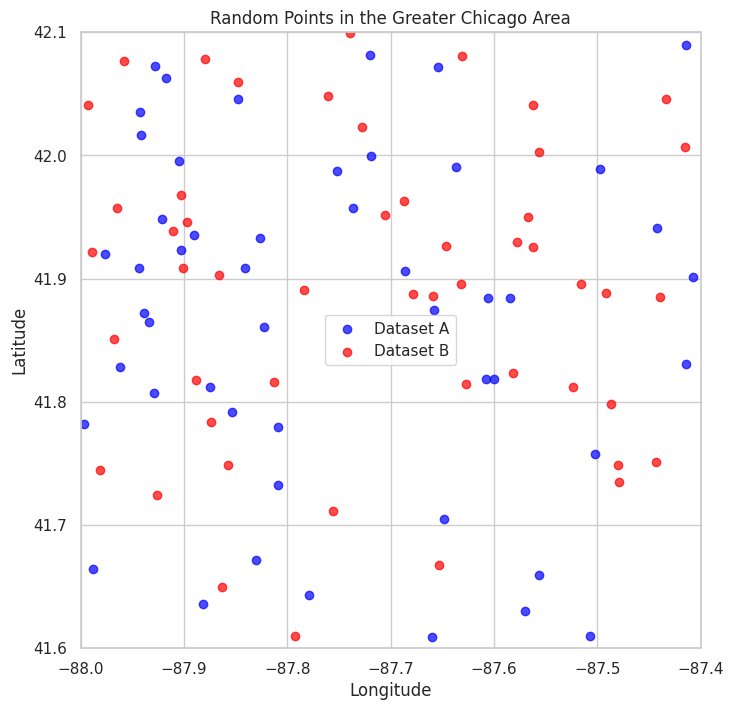

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Approximate bounding box for greater Chicago
lat_min, lat_max = 41.6, 42.1
lon_min, lon_max = -88.0, -87.4

# Create two random datasets
np.random.seed(0)

df_blue = pd.DataFrame({
    "lat": np.random.uniform(lat_min, lat_max, 50),
    "lon": np.random.uniform(lon_min, lon_max, 50)
})

df_red = pd.DataFrame({
    "lat": np.random.uniform(lat_min, lat_max, 50),
    "lon": np.random.uniform(lon_min, lon_max, 50)
})

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df_blue["lon"], df_blue["lat"], color="blue", label="Dataset A", alpha=0.7)
ax.scatter(df_red["lon"], df_red["lat"], color="red", label="Dataset B", alpha=0.7)

# Set map bounds
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Random Points in the Greater Chicago Area")

ax.legend()

plt.show()

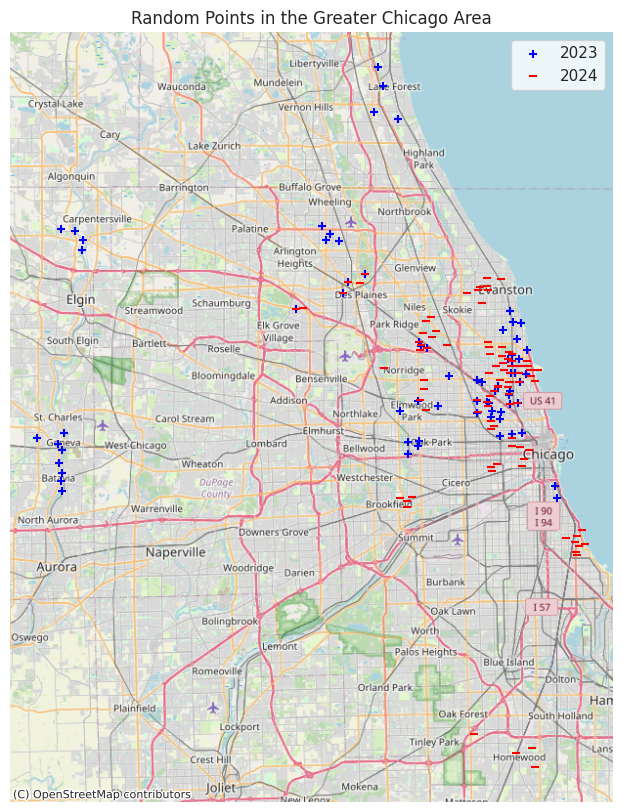

In [43]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

# Bounding box around Chicago
lat_min, lat_max = 41.6, 42.1
lon_min, lon_max = -88.0, -87.4

np.random.seed(0)

# Create two datasets
df_blue = pd.DataFrame({
    "lat": obs_geo_23['Latitude'],
    "lon": obs_geo_23['Longitude']
})

df_red = pd.DataFrame({
    "lat": obs_geo_24['Latitude'],
    "lon": obs_geo_24['Longitude']
})

# df_orange = pd.DataFrame({
#     "lat": obs_geo_25['Latitude'],
#     "lon": obs_geo_25['Longitude']
# })

# Convert to GeoDataFrames
gdf_blue = gpd.GeoDataFrame(
    df_blue,
    geometry=gpd.points_from_xy(df_blue.lon, df_blue.lat),
    crs="EPSG:4326"
)

gdf_red = gpd.GeoDataFrame(
    df_red,
    geometry=gpd.points_from_xy(df_red.lon, df_red.lat),
    crs="EPSG:4326"
)

# gdf_orange = gpd.GeoDataFrame(
#     df_orange,
#     geometry=gpd.points_from_xy(df_orange.lon, df_orange.lat),
#     crs="EPSG:4326"
# )

# Convert to Web Mercator for basemap tiles
gdf_blue = gdf_blue.to_crs(epsg=3857)
gdf_red = gdf_red.to_crs(epsg=3857)
# gdf_orange = gdf_orange.to_crs(epsg=3857)


# Plot
fig, ax = plt.subplots(figsize=(10,10))

gdf_blue.plot(ax=ax, color="blue", markersize=30, alpha=1, label="2023", marker='+')
gdf_red.plot(ax=ax, color="red", markersize=30, alpha=1, label="2024", marker='_')

# Add basemap
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.legend()
ax.set_axis_off()
plt.title("Random Points in the Greater Chicago Area")

plt.show()

## 3) Build minimal (no coverates) occupancy models for each year


In [ ]:
# Empty site covariate frame => intercept-only occupancy model
site_cov_minimal_25 = pd.DataFrame(index=obs_25.index)

minimal_fit_25 = fit(
    occu,
    site_covs=site_cov_minimal_25,
    obs_covs=obs_cov_empty_25,
    obs=obs_25,
    num_samples=NUM_SAMPLES,
    num_warmup=NUM_WARMUP,
    num_chains=NUM_CHAINS,
    random_seed=RANDOM_SEED,
)

# Print a quick summary
minimal_fit_25.mcmc.print_summary()

psi_mean_by_site_min_25 = minimal_fit_25.samples["psi"].mean(axis=0)
detection_mean_min_25 = minimal_fit_25.samples["prob_detection"].mean()

print(f"Posterior mean occupancy across sites: {psi_mean_by_site_min_25.mean():.3f}")
print(f"Posterior mean detection probability: {detection_mean_min_25:.3f}")

sample: 100%|██████████| 1000/1000 [00:01<00:00, 839.11it/s, 1 steps of size 9.38e-01. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.52      0.20      0.52      0.20      0.83   1239.33      1.00
   beta[0]     -0.45      0.18     -0.45     -0.73     -0.15   1112.64      1.00

Number of divergences: 0
Posterior mean occupancy across sites: 0.391
Posterior mean detection probability: 0.626


In [ ]:
minimal_fit_25.samples["psi"].shape

(1500, 137)

In [ ]:
# Empty site covariate frame => intercept-only occupancy model
site_cov_minimal_24 = pd.DataFrame(index=obs_24.index)

minimal_fit_24 = fit(
    occu,
    site_covs=site_cov_minimal_24,
    obs_covs=obs_cov_empty_24,
    obs=obs_24,
    num_samples=NUM_SAMPLES,
    num_warmup=NUM_WARMUP,
    num_chains=NUM_CHAINS,
    random_seed=RANDOM_SEED,
)

# Print a quick summary
minimal_fit_24.mcmc.print_summary()

psi_mean_by_site_min_24 = minimal_fit_24.samples["psi"].mean(axis=0)
detection_mean_min_24 = minimal_fit_24.samples["prob_detection"].mean()

print(f"Posterior mean occupancy across sites: {psi_mean_by_site_min_24.mean():.3f}")
print(f"Posterior mean detection probability: {detection_mean_min_24:.3f}")

sample: 100%|██████████| 1000/1000 [00:00<00:00, 1239.73it/s, 3 steps of size 8.95e-01. acc. prob=0.91]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.07      0.22      0.07     -0.29      0.44   1189.34      1.00
   beta[0]     -0.23      0.23     -0.23     -0.56      0.20   1108.88      1.00

Number of divergences: 0
Posterior mean occupancy across sites: 0.445
Posterior mean detection probability: 0.518


In [ ]:
minimal_fit_24.samples["psi"].shape

(1500, 98)

In [ ]:
# Empty site covariate frame => intercept-only occupancy model
site_cov_minimal_23 = pd.DataFrame(index=obs_23.index)

minimal_fit_23 = fit(
    occu,
    site_covs=site_cov_minimal_23,
    obs_covs=obs_cov_empty_23,
    obs=obs_23,
    num_samples=NUM_SAMPLES,
    num_warmup=NUM_WARMUP,
    num_chains=NUM_CHAINS,
    random_seed=RANDOM_SEED,
)

# Print a quick summary
minimal_fit_23.mcmc.print_summary()

psi_mean_by_site_min_23 = minimal_fit_23.samples["psi"].mean(axis=0)
detection_mean_min_23 = minimal_fit_23.samples["prob_detection"].mean()

print(f"Posterior mean occupancy across sites: {psi_mean_by_site_min_23.mean():.3f}")
print(f"Posterior mean detection probability: {detection_mean_min_23:.3f}")

sample: 100%|██████████| 1000/1000 [00:00<00:00, 1303.41it/s, 1 steps of size 8.48e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.44      0.26      0.44      0.05      0.86   1027.70      1.00
   beta[0]     -0.24      0.25     -0.24     -0.60      0.21   1439.67      1.00

Number of divergences: 0
Posterior mean occupancy across sites: 0.442
Posterior mean detection probability: 0.606


In [ ]:
minimal_fit_23.samples["psi"].shape

(1500, 71)

First I plotted the output of the model fairly directly to see how the occupancy and detection probability posteriors. While there is certainly variance, I didn't see a clear trend, and certainly didn't see anything confirming or negating my hypothosis that more sites would lead to better data.

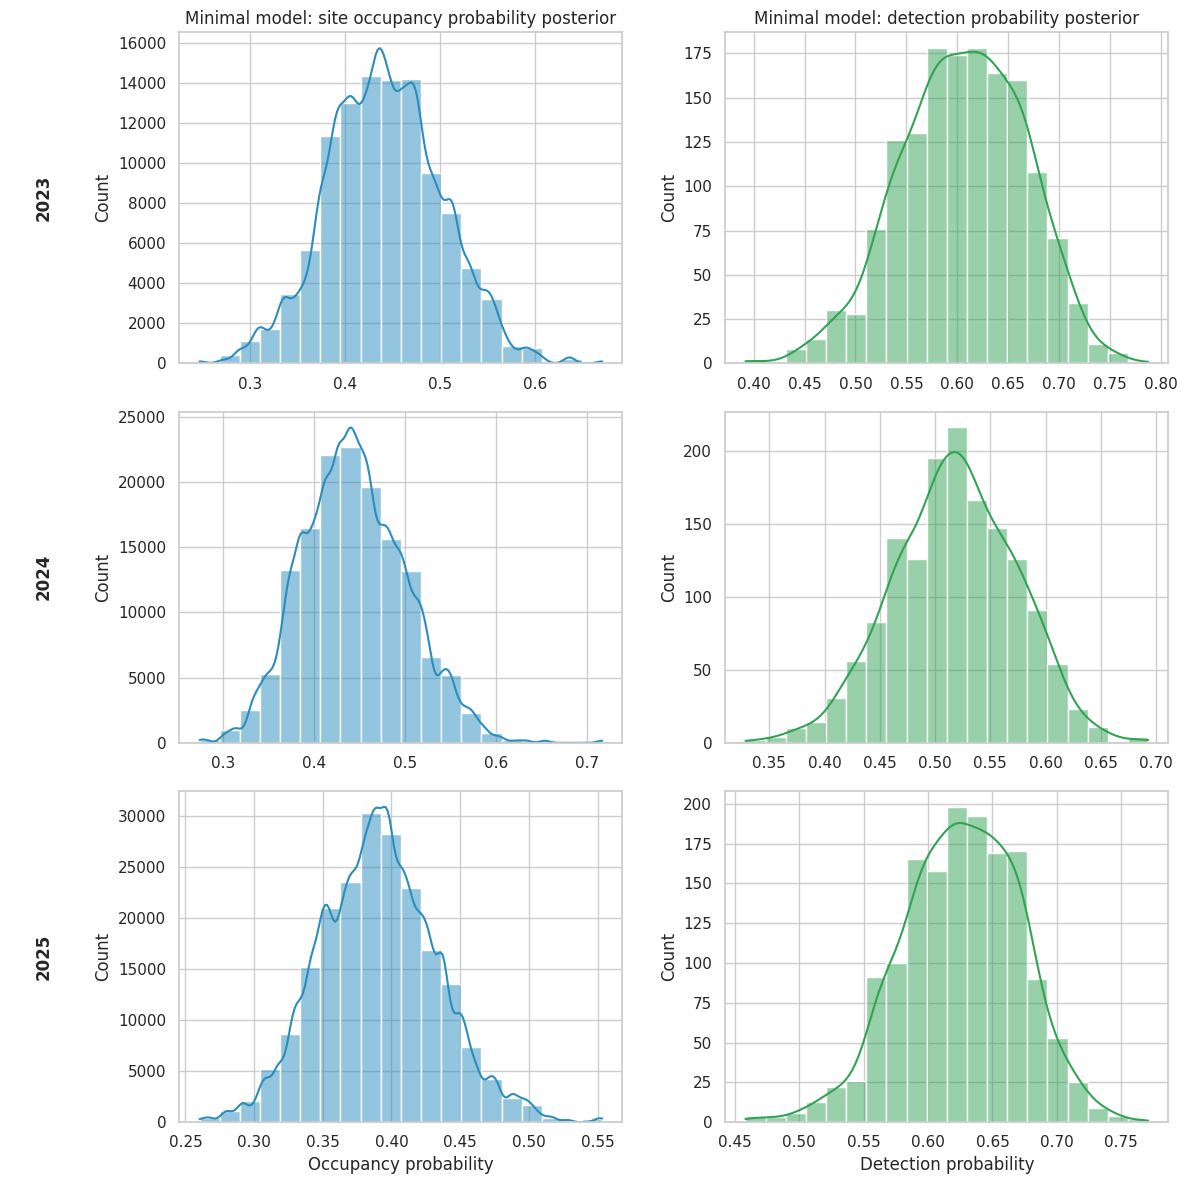

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 12))

# 3 rows, 3 columns (first column is narrow for labels)
gs = GridSpec(3, 3, figure=fig, width_ratios=[0.15, 1, 1])

row_labels = ["2023", "2024", "2025"]

# Data for plotting
psi_samples = [
    minimal_fit_23.samples["psi"].reshape(-1),
    minimal_fit_24.samples["psi"].reshape(-1),
    minimal_fit_25.samples["psi"].reshape(-1),
]
det_samples = [
    sigmoid(minimal_fit_23.samples["cov_det_0"].reshape(-1)),
    sigmoid(minimal_fit_24.samples["cov_det_0"].reshape(-1)),
    sigmoid(minimal_fit_25.samples["cov_det_0"].reshape(-1)),
]

for r in range(3):
    # Row label axis
    ax_label = fig.add_subplot(gs[r, 0])
    ax_label.axis("off")
    ax_label.text(
        0.5, 0.5,
        row_labels[r],
        rotation=90,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    # Occupancy probability histogram
    ax_psi = fig.add_subplot(gs[r, 1])
    sns.histplot(psi_samples[r], bins=20, kde=True, ax=ax_psi, color="#2b8cbe")
    if r == 0: # Only add title to the first row
        ax_psi.set_title("Minimal model: site occupancy probability posterior")
    if r == 2: # Only add xlabel to the last row
        ax_psi.set_xlabel("Occupancy probability")
    else:
        ax_psi.set_xlabel("") # Remove xlabel for middle rows

    # Detection probability histogram
    ax_det = fig.add_subplot(gs[r, 2])
    sns.histplot(det_samples[r], bins=20, kde=True, ax=ax_det, color="#31a354")
    if r == 0: # Only add title to the first row
        ax_det.set_title("Minimal model: detection probability posterior")
    if r == 2: # Only add xlabel to the last row
        ax_det.set_xlabel("Detection probability")
    else:
        ax_det.set_xlabel("") # Remove xlabel for middle rows


fig.tight_layout()
plt.show()


The plots below show the same data as box plots, plotted against the number of sites visitted. This does somewhat show an improvement by the last year, as the probability narrows, showing more confidence, for 2025.

/tmp/ipykernel_1171/1588587593.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Probability', data=psi_df, ax=ax1,
/tmp/ipykernel_1171/1588587593.py:54: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  ax1.legend(handles=box_legend_handles_1 + [site_legend_handle_1], labels=[h.get_label() for h in box_legend_handles_1] + [site_legend_label_1], loc='upper left')
/tmp/ipykernel_1171/1588587593.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Probability', data=det_df, ax=ax2,


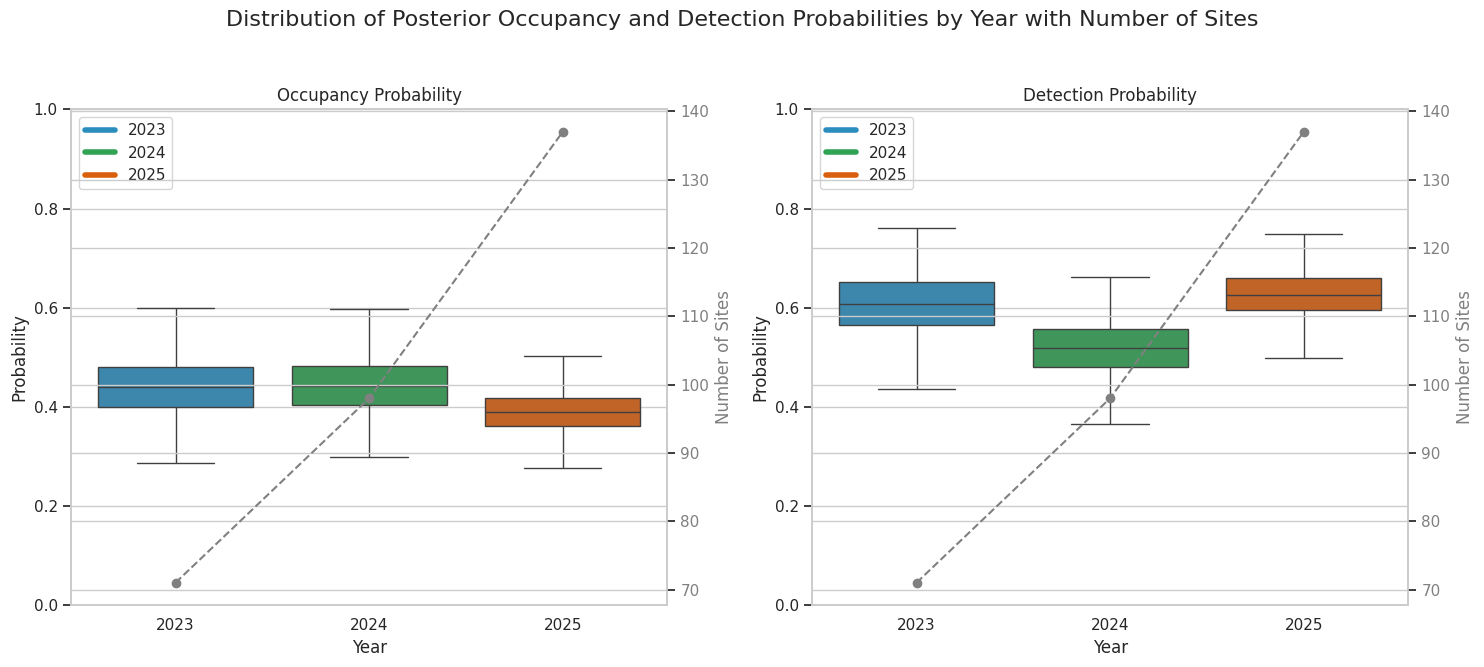

In [ ]:
# Prepare data from minimal_fit objects

# Get number of sites for each year
n_sites_23 = minimal_fit_23.samples["psi"].shape[1]
n_sites_24 = minimal_fit_24.samples["psi"].shape[1]
n_sites_25 = minimal_fit_25.samples["psi"].shape[1]

n_sites_values = [n_sites_23, n_sites_24, n_sites_25]

years = ['2023', '2024', '2025']

# Prepare data for seaborn boxplots
all_psi_samples = np.concatenate([psi_samples[0], psi_samples[1], psi_samples[2]])
all_det_samples = np.concatenate([det_samples[0], det_samples[1], det_samples[2]])
all_years_psi = ['2023']*len(psi_samples[0]) + ['2024']*len(psi_samples[1]) + ['2025']*len(psi_samples[2])
all_years_det = ['2023']*len(det_samples[0]) + ['2024']*len(det_samples[1]) + ['2025']*len(det_samples[2])

psi_df = pd.DataFrame({'Probability': all_psi_samples, 'Year': all_years_psi})
det_df = pd.DataFrame({'Probability': all_det_samples, 'Year': all_years_det})

# Define colors (matching plotly output)
colors = {'2023': '#2b8cbe', '2024': '#31a354', '2025': '#d95f0e'}
site_line_color = 'gray'

# Create the figure and two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Distribution of Posterior Occupancy and Detection Probabilities by Year with Number of Sites", fontsize=16)

# --- Occupancy Probability Subplot (Left Column) ---
ax1 = axes[0]
ax1_secondary = ax1.twinx() # Create a secondary y-axis

# Plot box plots for Occupancy Probability
sns.boxplot(x='Year', y='Probability', data=psi_df, ax=ax1,
            palette=colors, showfliers=False,  # showfliers=False is equivalent to Plotly's boxpoints=False
            legend=False) # Manual legend creation below

# Plot Number of Sites on the secondary y-axis
ax1_secondary.plot(years, n_sites_values, color=site_line_color, linestyle='--', marker='o', label='Number of Sites')

# Set titles and labels for the first subplot
ax1.set_title("Occupancy Probability")
ax1.set_xlabel("Year")
ax1.set_ylabel("Probability")
ax1_secondary.set_ylabel("Number of Sites", color=site_line_color)
ax1_secondary.tick_params(axis='y', labelcolor=site_line_color) # Set color for secondary y-axis labels
ax1.set_ylim(0, 1) # Probabilities are between 0 and 1

# Create custom legend handles for the box plots for each year
box_legend_handles_1 = [plt.Line2D([0], [0], color=colors[year], lw=4, label=year) for year in years]
# Get the handle for 'Number of Sites' from the secondary axis plot
site_legend_handle_1, site_legend_label_1 = ax1_secondary.get_legend_handles_labels()[0], ax1_secondary.get_legend_handles_labels()[1][0]
# Combine and display legend for ax1
ax1.legend(handles=box_legend_handles_1 + [site_legend_handle_1], labels=[h.get_label() for h in box_legend_handles_1] + [site_legend_label_1], loc='upper left')


# --- Detection Probability Subplot (Right Column) ---
ax2 = axes[1]
ax2_secondary = ax2.twinx() # Create a secondary y-axis

# Plot box plots for Detection Probability
sns.boxplot(x='Year', y='Probability', data=det_df, ax=ax2,
            palette=colors, showfliers=False,
            legend=False) # Manual legend creation below

# Plot Number of Sites on the secondary y-axis (no label here to avoid duplicate legend entry for 'Number of Sites')
ax2_secondary.plot(years, n_sites_values, color=site_line_color, linestyle='--', marker='o')

# Set titles and labels for the second subplot
ax2.set_title("Detection Probability")
ax2.set_xlabel("Year")
ax2.set_ylabel("Probability")
ax2_secondary.set_ylabel("Number of Sites", color=site_line_color)
ax2_secondary.tick_params(axis='y', labelcolor=site_line_color) # Set color for secondary y-axis labels
ax2.set_ylim(0, 1) # Probabilities are between 0 and 1

# Create custom legend handles for the box plots for each year (only year legends for ax2)
box_legend_handles_2 = [plt.Line2D([0], [0], color=colors[year], lw=4, label=year) for year in years]
ax2.legend(handles=box_legend_handles_2, labels=[h.get_label() for h in box_legend_handles_2], loc='upper left')


# Final layout adjustments
fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for the suptitle
plt.show()

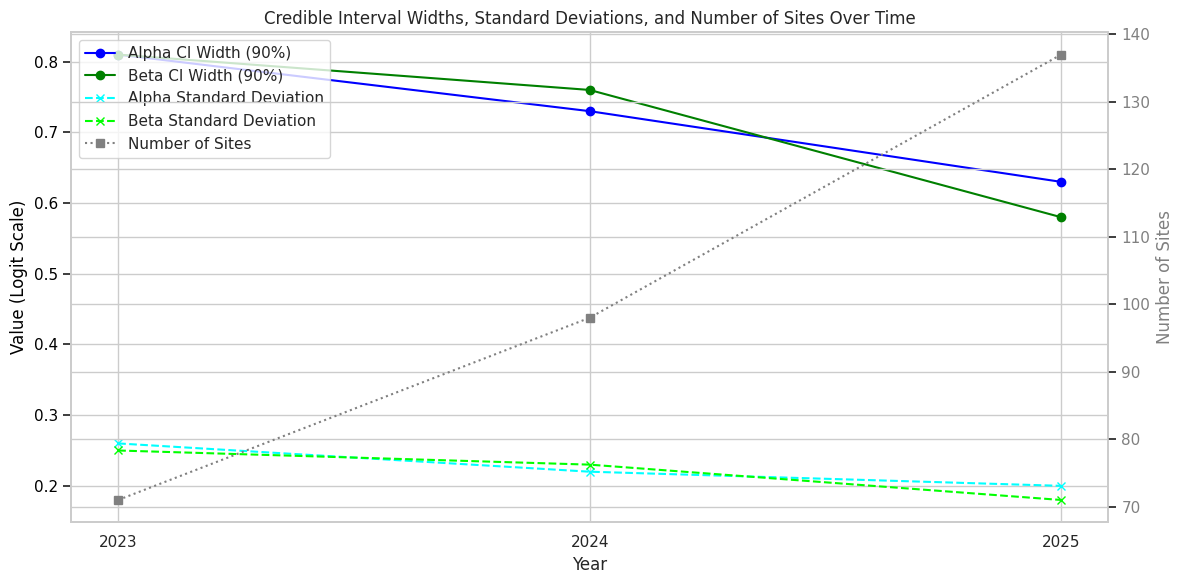

In [ ]:
years = ['2023', '2024', '2025']

"""
2023
                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.44      0.26      0.44      0.05      0.86   1027.70      1.00
   beta[0]     -0.24      0.25     -0.24     -0.60      0.21   1439.67      1.00

2024
                mean       std    median      5.0%     95.0%     n_eff     r_hat
  alpha[0]      0.07      0.22      0.07     -0.29      0.44   1189.34      1.00
   beta[0]     -0.23      0.23     -0.23     -0.56      0.20   1108.88      1.00

2025
  alpha[0]      0.52      0.20      0.52      0.20      0.83   1239.33      1.00
   beta[0]     -0.45      0.18     -0.45     -0.73     -0.15   1112.64      1.00

"""


# Calculate the 90% credible interval width for alpha
alpha_ci_width = [0.86 - 0.05, 0.44 - -0.29, 0.83 - 0.20]

# Calculate the 90% credible interval width for beta
beta_ci_width = [0.21 - -0.60, 0.20 - -0.56, -0.15 - -0.73]

alpha_std_devs = [0.26, 0.22, 0.20]
beta_std_devs = [0.25, 0.23, 0.18]

# Get number of sites for each year
n_sites_23 = minimal_fit_23.samples["psi"].shape[1]
n_sites_24 = minimal_fit_24.samples["psi"].shape[1]
n_sites_25 = minimal_fit_25.samples["psi"].shape[1]

years = ['2023', '2024', '2025']
n_sites_values = [n_sites_23, n_sites_24, n_sites_25]

# Create figure and a single subplot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot credible interval widths and standard deviations on the primary y-axis (ax1)
ax1.plot(years, alpha_ci_width, marker='o', linestyle='-', color='blue', label='Alpha CI Width (90%)')
ax1.plot(years, beta_ci_width, marker='o', linestyle='-', color='green', label='Beta CI Width (90%)')
ax1.plot(years, alpha_std_devs, marker='x', linestyle='--', color='cyan', label='Alpha Standard Deviation')
ax1.plot(years, beta_std_devs, marker='x', linestyle='--', color='lime', label='Beta Standard Deviation')

ax1.set_xlabel('Year')
ax1.set_ylabel('Value (Logit Scale)', color='black') # General label for CI/Std Devs
ax1.tick_params(axis='y', labelcolor='black')

# Create a secondary y-axis for the number of sites
ax2 = ax1.twinx()
ax2.plot(years, n_sites_values, marker='s', linestyle=':', color='gray', label='Number of Sites')
ax2.set_ylabel('Number of Sites', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# Add title and legend
plt.title('Credible Interval Widths, Standard Deviations, and Number of Sites Over Time')

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Task
create_combined_histogram_grid

## create_combined_histogram_grid

### Subtask:
Generate a 3x2 grid of subplots displaying occupancy and detection probability distributions for each year (2023, 2024, 2025).


## Summary:

### Data Analysis Key Findings
*   A 3x2 grid of subplots was successfully generated, displaying the distributions of 'occupancy' and 'detection probability' for each of the years 2023, 2024, and 2025. This visualization provides a comparative view of these key metrics across the specified years.

### Insights or Next Steps
*   Proceed with a detailed visual analysis of the generated histograms to identify any discernible trends, shifts, or significant differences in occupancy and detection probability distributions across the years 2023, 2024, and 2025.
*   Based on visual observations, consider performing quantitative comparisons or statistical tests to validate any perceived differences or trends in the distributions over time.
